# Uplift modeling for Better ROI

### Data Simulation

In [3]:
#! pip install duecredit

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from causalml.dataset import synthetic_data
warnings.filterwarnings("ignore", message=".*force_all_finite.*")
np.random.seed(42)

y, X, T, _, _, e = synthetic_data(mode=1, n=5000, p=9, sigma=1)
df = pd.DataFrame(X, columns=[f"x{i+1}" for i in range(X.shape[1])])
df["Y"] = y
df["T"] = T
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,Y,T
0,0.374540,0.950714,0.731994,0.598658,0.156019,0.155995,0.058084,0.866176,0.601115,1.996076,1
1,0.708073,0.020584,0.969910,0.832443,0.212339,0.181825,0.183405,0.304242,0.524756,2.451140,0
2,0.431945,0.291229,0.611853,0.139494,0.292145,0.366362,0.456070,0.785176,0.199674,1.501664,1
3,0.514234,0.592415,0.046450,0.607545,0.170524,0.065052,0.948886,0.965632,0.808397,0.840369,0
4,0.304614,0.097672,0.684233,0.440152,0.122038,0.495177,0.034389,0.909320,0.258780,2.348931,0


In [5]:
feature_cols = ['x1','x2','x3','x4','x5','x6','x7','x8','x9']
outcome_col = 'Y'
treat_col = 'T'
df.groupby(treat_col)['Y'].agg(['count','mean'])

,count,mean
T,,
0,2392,1.080164
1,2608,1.961395


In [6]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df,test_size=0.3,random_state=42, stratify=df["T"])
df_train.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,Y,T
1521,0.794352,0.490478,0.039806,0.763019,0.168569,0.631474,0.085664,0.946867,0.291724,2.094582,1
1249,0.874252,0.171011,0.425869,0.187173,0.773304,0.474373,0.351144,0.361100,0.852214,1.121305,1
4177,0.985538,0.875774,0.296403,0.507946,0.230841,0.514504,0.683332,0.085521,0.870117,2.031686,0
1981,0.653290,0.233996,0.183662,0.009954,0.471643,0.428646,0.233868,0.053652,0.429256,-0.510845,1
3555,0.558097,0.839283,0.762909,0.118656,0.245554,0.026658,0.007961,0.224375,0.799321,1.792929,1


## Modeling Method 1: with CausalML Directly

In [7]:
from causalml.inference.meta import BaseTRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Initialize Learner with any base learner
# learner = BaseTRegressor(learner=GradientBoostingRegressor())
learner = BaseTRegressor(learner=LinearRegression())

# Fit the model
learner.fit(X=df_train[feature_cols], treatment=df_train[treat_col], y=df_train[outcome_col])
# Predict uplift
uplift_hat_m1 = learner.predict(df_test[feature_cols])

In [8]:
def deciles(
    df_scored: pd.DataFrame,
    uplift_hat,
    decile_col: str = "decile",
    treat_col: str = "T",
    outcome_col: str = "Y", # Y is continuous (e.g., revenue or count)
    uplift_pred_col: str = "uplift_hat"
):
    df = df_scored.copy()
    q = 10
    df[uplift_pred_col] = uplift_hat

    # Rank and assign deciles (1 = highest predicted uplift)
    rank = df[uplift_pred_col].rank(method="first", ascending=False)
    df[decile_col] = (pd.qcut(rank, q=q, labels=False) + 1).astype(int)

    grouped = df.groupby(decile_col, sort=True)

    # Base counts
    base = grouped.agg(
        n=(outcome_col, "size"),
        n_treated=(treat_col, lambda s: int((s == 1).sum()))
    ).sort_index()
    base["n_untreated"] = base["n"] - base["n_treated"]

    # Treated/untreated mean outcome per decile (explicit means)
    means = (
        df.groupby([decile_col, treat_col])[outcome_col]
          .mean()
          .unstack(fill_value=np.nan)
          .rename(columns={0: "untreated_Y", 1: "treated_Y"})
          .sort_index().round(2)
    )

    # Join and compute actual uplift (= mean difference)
    summary = (
        base.join(means, how="left")
            .join(grouped[uplift_pred_col].mean().rename("uplift_pred"), how="left")
            .reset_index()
            .sort_values(decile_col).round(2)
    )
    summary["uplift"] = summary["treated_Y"] - summary["untreated_Y"]

    # Incremental outcome units per decile
    summary["incre_sum"] = summary["uplift"] * summary["n_treated"]

    # Cumulative metrics for the uplift curve
    summary["cum_incre_ttl"] = summary["incre_sum"].cumsum()
    summary["cum_n"] = summary["n"].cumsum()
    total_n = summary["n"].sum()
    summary["cum_coverage"] = summary["cum_n"] / total_n  # in [0,1]
    total_incremental_units = summary["incre_sum"].sum()

    return summary, df
    
summary_m1, test_scored_m1 = deciles(
    df_scored=df_test,
    uplift_hat=uplift_hat_m1)

summary_m1

,decile,n,n_treated,n_untreated,untreated_Y,treated_Y,uplift_pred,uplift,incre_sum,cum_incre_ttl,cum_n,cum_coverage
0,1,150,112,38,1.14,2.12,1.11,0.98,109.76,109.76,150,0.1
1,2,150,127,23,1.53,2.28,0.94,0.75,95.25,205.01,300,0.2
2,3,150,117,33,1.61,2.19,0.85,0.58,67.86,272.87,450,0.3
3,4,150,108,42,1.28,2.05,0.78,0.77,83.16,356.03,600,0.4
4,5,150,99,51,1.24,1.83,0.71,0.59,58.41,414.44,750,0.5
5,6,150,79,71,1.11,1.89,0.65,0.78,61.62,476.06,900,0.6
6,7,150,53,97,1.07,1.46,0.57,0.39,20.67,496.73,1050,0.7
7,8,150,49,101,0.97,1.43,0.49,0.46,22.54,519.27,1200,0.8
8,9,150,23,127,0.92,1.40,0.39,0.48,11.04,530.31,1350,0.9
9,10,150,15,135,1.00,1.17,0.23,0.17,2.55,532.86,1500,1.0


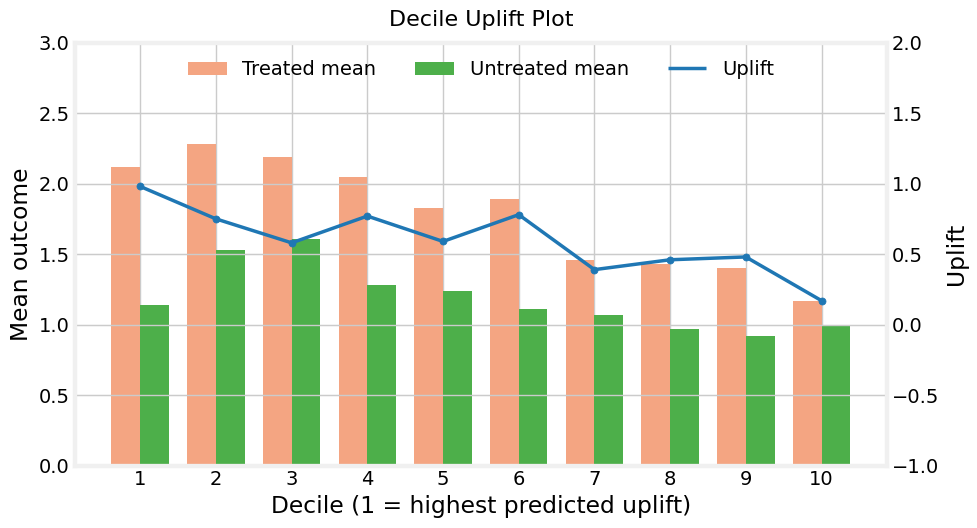

In [9]:
def plot_deciles(
    df: pd.DataFrame,
    decile_col: str = "decile",
    treated_col: str = "treated_Y",
    untreated_col: str = "untreated_Y",
    title: str = "Decile Uplift Plot"
):

    # Sort by decile to ensure left-to-right
    d = df.sort_values(decile_col).reset_index(drop=True)
    d[decile_col] = d[decile_col].astype(int)
    bin_labels = d[decile_col]

    treated = d[treated_col].astype(float).to_numpy()
    untreated = d[untreated_col].astype(float).to_numpy()
    uplift = treated - untreated

    # Positions for side-by-side bars
    n = len(bin_labels)
    x = np.arange(n)
    bar_width = 0.38

    # Colors
    color_treated = "#f4a582"   # peach
    color_untreated = "#4daf4a" # green
    color_line = "#1f77b4"      # blue

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="white")
    ax.set_facecolor("white")

    # Bars: treated vs. untreated mean outcome
    ax.bar(x - bar_width/2, treated, width=bar_width, label="Treated mean", color=color_treated)
    ax.bar(x + bar_width/2, untreated, width=bar_width, label="Untreated mean", color=color_untreated)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)
    ax.set_title(title, fontsize=16, pad=12)
    ax.set_xlabel("Decile (1 = highest predicted uplift)")
    ax.set_ylabel("Mean outcome")
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0,3)
    
    # Uplift line on right y-axis (treated - untreated)
    ax2 = ax.twinx()
    ax2.plot(x, uplift, color=color_line, linewidth=2.5, label="Uplift")
    ax2.scatter(x, uplift, color=color_line, s=26)
    ax2.set_ylabel("Uplift")
    ax2.set_ylim(-1,2)

    # Legend combining both axes
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, loc="upper center", ncol=3, frameon=False)

    plt.tight_layout()
    plt.show()

plot_deciles(
    df=summary_m1,
    decile_col="decile",
    treated_col="treated_Y",
    untreated_col="untreated_Y",
    title="Decile Uplift Plot"
)

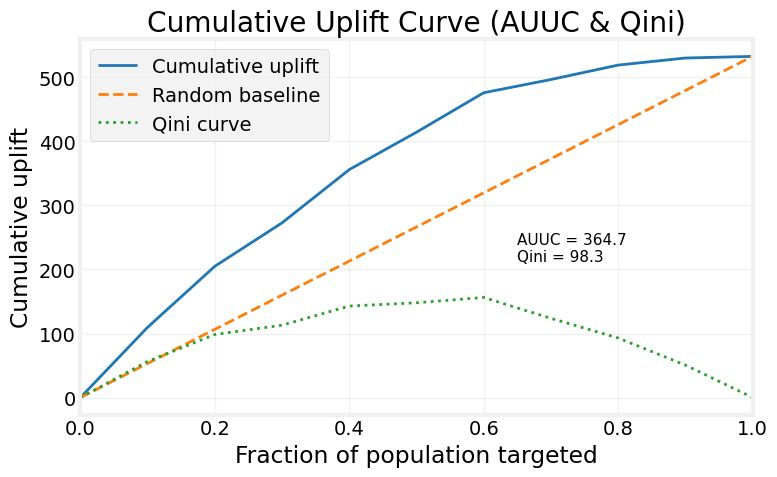

364.69100000000003 98.26100000000004


In [13]:
def auuc_qini(
    decile_df: pd.DataFrame,
    coverage_col: str = "cum_coverage",
    cum_uplift_col: str = "cum_incre_ttl",
    title: str = "Cumulative Uplift Curve (AUUC & Qini)"
):

    # Ensure sorted by coverage (left to right)
    d = decile_df.sort_values(coverage_col).reset_index(drop=True)

    # X and Y for the curve
    x = d[coverage_col].to_numpy()
    y = d[cum_uplift_col].to_numpy()

    # Guard: ensure first point starts at 0 coverage & 0 uplift (optional, but typical)
    # If not, prepend a zero point to anchor the curve.
    if len(x) == 0 or x[0] > 0.0 or y[0] != 0.0:
        x = np.insert(x, 0, 0.0)
        y = np.insert(y, 0, 0.0)

    # Total cumulative uplift at full coverage
    total_cum_uplift = float(y[-1])

    # Baseline: random targeting accumulates linearly with coverage
    baseline = x * total_cum_uplift

    # AUUC: area under the cumulative uplift curve
    auuc = float(np.trapezoid(y, x))
    # Qini: area between model curve and random baseline
    qini = float(np.trapezoid(y - baseline, x))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.plot(x, y, label="Cumulative uplift", color="#1f77b4", linewidth=2)
    ax.plot(x, baseline, label="Random baseline", color="#ff7f0e", linestyle="--", linewidth=2)
    ax.plot(x, y - baseline, label="Qini curve", color="#2ca02c", linestyle=":", linewidth=2)

    ax.set_xlabel("Fraction of population targeted")
    ax.set_ylabel("Cumulative uplift")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    # y-limit auto; you can set ax.set_ylim(bottom=0) if uplift is always non-negative
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    # Annotate AUUC/Qini in-plot
    ymin, ymax = float(np.nanmin(y)), float(np.nanmax(y))
    y_annot = ymin + 0.4 * (ymax - ymin) if ymax > ymin else 0.0
    ax.annotate(f"AUUC = {auuc:.1f}\nQini = {qini:.1f}",
                xy=(0.65, y_annot), fontsize=11)

    plt.tight_layout()
    plt.show()

    curve_df = pd.DataFrame({"coverage": x, "cum_uplift": y, "baseline": baseline})
    return {"AUUC": auuc, "Qini": qini, "curve_df": curve_df}

metrics = auuc_qini(
    decile_df=summary_m1,
    coverage_col="cum_coverage",
    cum_uplift_col="cum_incre_ttl",
    title="Cumulative Uplift Curve (AUUC & Qini)"
)

print(metrics["AUUC"], metrics["Qini"])


### Feature Importance & SHAP

<Figure size 500x300 with 0 Axes>

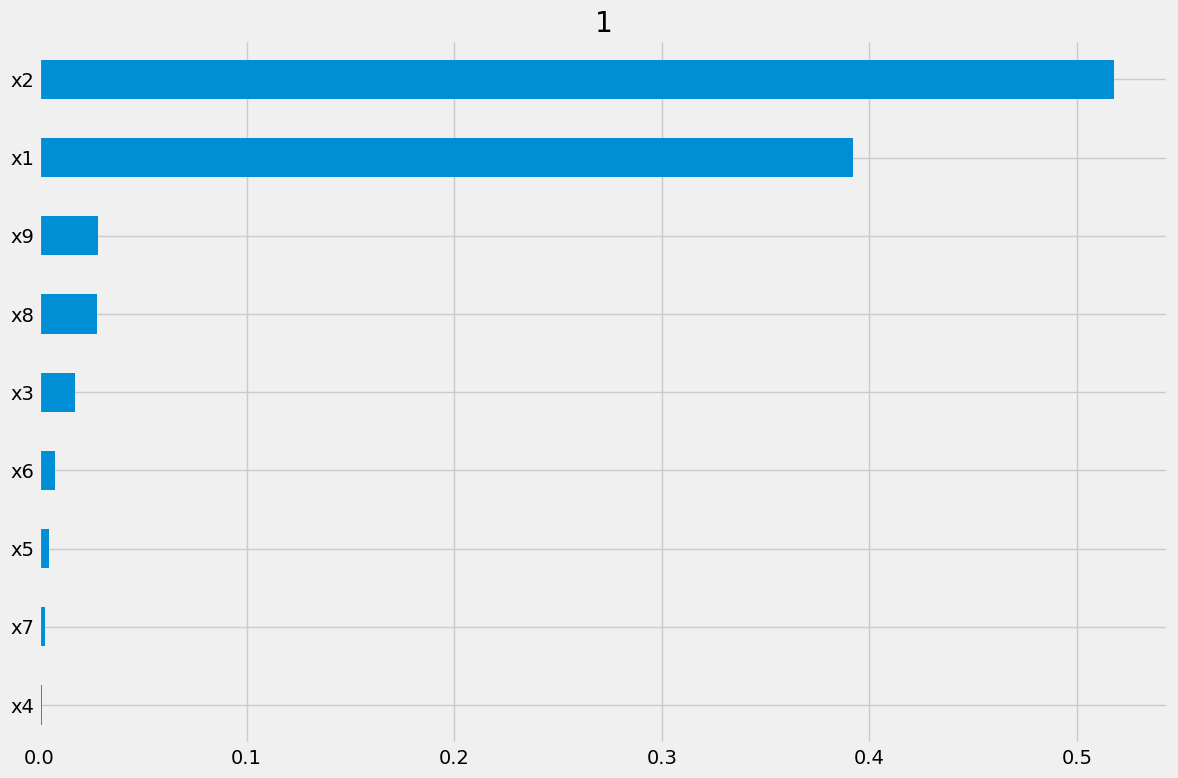

In [14]:
model_tau_feature = GradientBoostingRegressor()
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))   # make it smaller; adjust as needed, e.g., (4, 2.5)
learner.plot_importance(
    X=df_test[feature_cols],
    tau=uplift_hat_m1,
    model_tau_feature=model_tau_feature,
    features=feature_cols,
    normalize=True,
    method='auto'
)

plt.tight_layout()
plt.gcf().savefig("uplift_feature_importance.png", dpi=100, bbox_inches="tight")

#### SHAP
https://causalml.readthedocs.io/en/latest/interpretation.html

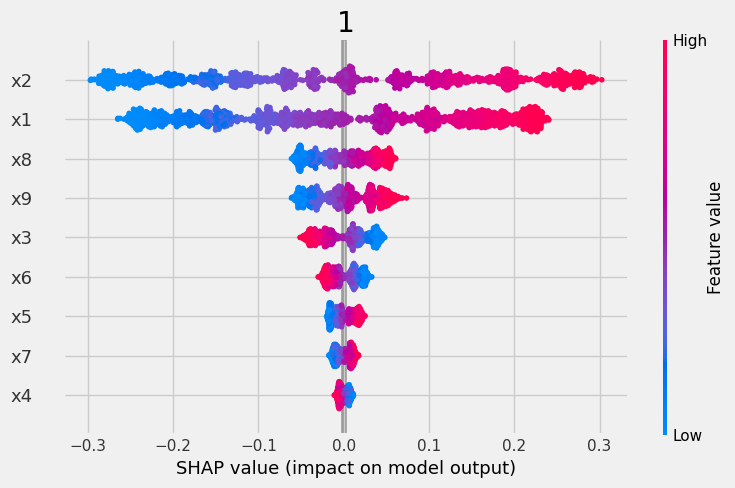

In [15]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 3))
learner.plot_shap_values(
    X=df_test[feature_cols],
    model_tau_feature=model_tau_feature,
    features=feature_cols,
    tau=uplift_hat_m1
)
fig.tight_layout()
fig.savefig("uplift_shap.png", dpi=150, bbox_inches="tight")

In [16]:
# Using SHAP
shap_learner = learner.get_shap_values(X=df_test[feature_cols], 
                                       model_tau_feature=model_tau_feature,
                                       tau=uplift_hat_m1)

## Modeling Method 2: Treated and Controlled Separately

In [17]:
from sklearn.linear_model import LinearRegression
# Define the learners
model_treated = LinearRegression()
model_control = LinearRegression()

# Fit treated model on T == 1
treated_group = df_train["T"] == 1
model_treated.fit(df_train.loc[treated_group, feature_cols],
                  df_train.loc[treated_group, "Y"])

# Fit control model on T == 0
control_group = df_train["T"] == 0
model_control.fit(df_train.loc[control_group, feature_cols],
                  df_train.loc[control_group, "Y"])

# Predict potential outcomes for test set
mu1_hat = model_treated.predict(df_test[feature_cols])  # E[Y|T=1, X]
mu0_hat = model_control.predict(df_test[feature_cols])  # E[Y|T=0, X]

# Compute uplift
uplift_hat_m2 = mu1_hat - mu0_hat

# Check first few predictions
print("Predicted uplift:", uplift_hat_m2[:10])

Predicted uplift: [0.77756263 0.41684063 0.54991287 0.94474721 0.73796149 0.95367667
 0.72884993 0.55265746 0.94147656 0.73323998]


In [18]:
summary_m2, test_scored_m2 = deciles(
    df_scored=df_test,
    uplift_hat=uplift_hat_m2)

summary_m2

,decile,n,n_treated,n_untreated,untreated_Y,treated_Y,uplift_pred,uplift,incre_sum,cum_incre_ttl,cum_n,cum_coverage
0,1,150,112,38,1.14,2.12,1.11,0.98,109.76,109.76,150,0.1
1,2,150,127,23,1.53,2.28,0.94,0.75,95.25,205.01,300,0.2
2,3,150,117,33,1.61,2.19,0.85,0.58,67.86,272.87,450,0.3
3,4,150,108,42,1.28,2.05,0.78,0.77,83.16,356.03,600,0.4
4,5,150,99,51,1.24,1.83,0.71,0.59,58.41,414.44,750,0.5
5,6,150,79,71,1.11,1.89,0.65,0.78,61.62,476.06,900,0.6
6,7,150,53,97,1.07,1.46,0.57,0.39,20.67,496.73,1050,0.7
7,8,150,49,101,0.97,1.43,0.49,0.46,22.54,519.27,1200,0.8
8,9,150,23,127,0.92,1.40,0.39,0.48,11.04,530.31,1350,0.9
9,10,150,15,135,1.00,1.17,0.23,0.17,2.55,532.86,1500,1.0


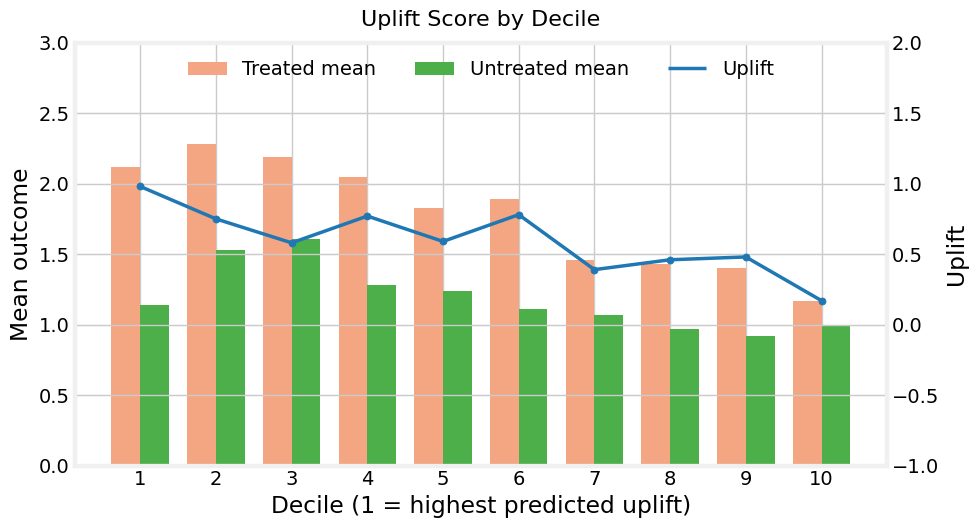

In [19]:
plot_deciles(
    df=summary_m2,
    decile_col="decile",
    treated_col="treated_Y",
    untreated_col="untreated_Y",
    title="Uplift Score by Decile"
)

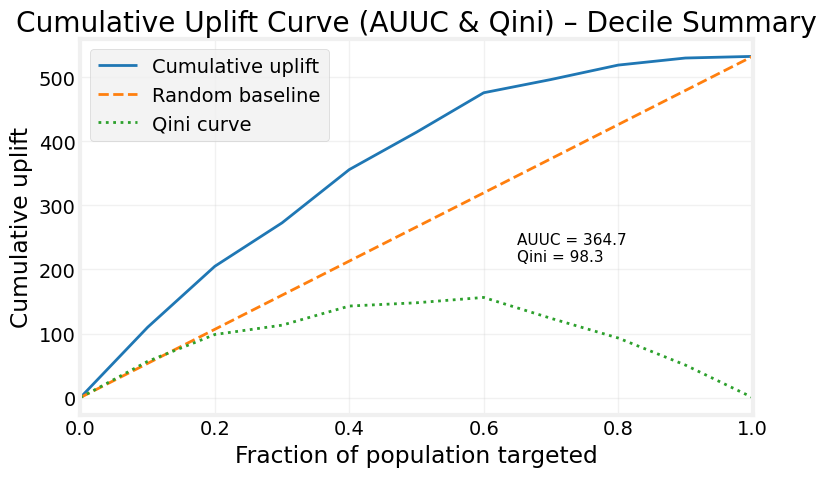

364.69100000000003 98.26100000000004


In [20]:
metrics = auuc_qini(
    decile_df=summary_m2,
    coverage_col="cum_coverage",
    cum_uplift_col="cum_incre_ttl",
    title="Cumulative Uplift Curve (AUUC & Qini) – Decile Summary"
)

print(metrics["AUUC"], metrics["Qini"])